In [1]:
!pip install kaggle

In [2]:
!kaggle datasets download -d adityachandrasekhar/image-super-resolution

Dataset URL: https://www.kaggle.com/datasets/adityachandrasekhar/image-super-resolution
License(s): unknown
image-super-resolution.zip: Skipping, found more recently modified local copy (use --force to force download)


In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (2).json


{'kaggle (2).json': b'{"username":"rhythmgaba002","key":"53f7746a9cfe2d81128ccadb0fa62183"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
import zipfile
import os
import cv2
import numpy as np
from tensorflow.keras.layers import Conv2D, UpSampling2D, LeakyReLU, Add, Input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense
import matplotlib.pyplot as plt

In [6]:
with zipfile.ZipFile('image-super-resolution.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

In [7]:
train_lr_path = '/content/dataset/dataset/train/low_res'
train_hr_path = '/content/dataset/dataset/train/high_res'

val_lr_path = '/content/dataset/dataset/val/low_res'
val_hr_path = '/content/dataset/dataset/val/high_res'

In [8]:
def load_paired_images(lr_path, hr_path, lr_size=(64,64), hr_size=(256,256)):
    lr_images = []
    hr_images = []

    files = sorted(os.listdir(lr_path))   # important for pairing

    for file in files:
        lr_img = cv2.imread(os.path.join(lr_path, file))
        hr_img = cv2.imread(os.path.join(hr_path, file))

        lr_img = cv2.resize(lr_img, lr_size)
        hr_img = cv2.resize(hr_img, hr_size)

        lr_img = lr_img / 255.0
        hr_img = hr_img / 255.0

        lr_images.append(lr_img)
        hr_images.append(hr_img)

    return np.array(lr_images), np.array(hr_images)

In [9]:
X_train, y_train = load_paired_images(train_lr_path, train_hr_path)
X_val, y_val = load_paired_images(val_lr_path, val_hr_path)

print(X_train.shape, y_train.shape)

(685, 64, 64, 3) (685, 256, 256, 3)


In [10]:
def build_generator():
    inputs = Input(shape=(64,64,3))
    x = UpSampling2D()(inputs)

    x = Conv2D(64, 9, padding='same')(x)

    x = UpSampling2D()(x)

    outputs = Conv2D(3, 3, activation='sigmoid', padding='same')(x)

    return Model(inputs, outputs)

In [11]:
def build_discriminator():
    inputs = Input(shape=(256,256,3))

    x = Conv2D(64, 3, strides=2, padding='same')(inputs)
    x = LeakyReLU()(x)

    x = Conv2D(128, 3, strides=2, padding='same')(x)
    x = LeakyReLU()(x)

    x = Flatten()(x)
    outputs = Dense(1, activation='sigmoid')(x)

    return Model(inputs, outputs)

In [12]:
def residual_block(x):
    res = Conv2D(64, 3, padding='same')(x)
    res = LeakyReLU()(res)
    res = Conv2D(64, 3, padding='same')(res)
    return Add()([x, res])

In [13]:
def build_srgan():
    inputs = Input(shape=(64,64,3))

    x = Conv2D(64, 9, padding='same')(inputs)

    for _ in range(5):
        x = residual_block(x)

    x = UpSampling2D()(x)
    x = UpSampling2D()(x)

    outputs = Conv2D(3, 9, activation='sigmoid', padding='same')(x)

    return Model(inputs, outputs)

In [14]:
def dense_block(x):
    d1 = Conv2D(64, 3, padding='same')(x)
    d1 = LeakyReLU()(d1)

    d2 = Conv2D(64, 3, padding='same')(d1)
    d2 = LeakyReLU()(d2)

    return Add()([x, d2])

In [15]:
def build_esrgan():
    inputs = Input(shape=(64,64,3))

    x = Conv2D(64, 3, padding='same')(inputs)

    for _ in range(5):
        x = dense_block(x)

    x = UpSampling2D()(x)
    x = UpSampling2D()(x)

    outputs = Conv2D(3, 3, activation='sigmoid', padding='same')(x)

    return Model(inputs, outputs)

In [16]:
gan_gen = build_generator()
disc = build_discriminator()
srgan_gen = build_srgan()
esrgan_gen = build_esrgan()

disc.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
gan_gen.compile(optimizer='adam', loss='mse')
srgan_gen.compile(optimizer='adam', loss='mse')
esrgan_gen.compile(optimizer='adam', loss='mse')

In [17]:
def build_gan(generator, discriminator):
    discriminator.trainable = False   # freeze discriminator

    inp = Input(shape=(64,64,3))
    fake_img = generator(inp)

    validity = discriminator(fake_img)

    model = Model(inp, validity)
    model.compile(optimizer='adam', loss='binary_crossentropy')

    return model

In [18]:
gan_model = build_gan(gan_gen, disc)
srgan_model = build_gan(srgan_gen, disc)
esrgan_model = build_gan(esrgan_gen, disc)

In [19]:
def train_gan(generator, gan_model, name, epochs=20, batch_size=4):
    print(f"\nTraining {name}...\n")

    for epoch in range(epochs):

        idx = np.random.randint(0, X_train.shape[0], batch_size)

        lr = X_train[idx]
        hr = y_train[idx]

        fake = generator.predict(lr)

        # Train Discriminator
        d_loss_real = disc.train_on_batch(hr, np.ones((batch_size,1)))
        d_loss_fake = disc.train_on_batch(fake, np.zeros((batch_size,1)))

        # Train Generator via GAN
        g_loss = gan_model.train_on_batch(lr, np.ones((batch_size,1)))

        print(f"{name} Epoch {epoch+1}: D={d_loss_real + d_loss_fake}, G={g_loss}")

In [20]:
train_gan(gan_gen, gan_model, "GAN")
train_gan(srgan_gen, srgan_model, "SRGAN")
train_gan(esrgan_gen, esrgan_model, "ESRGAN")


Training GAN...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


GAN Epoch 1: D=[array(0.725953, dtype=float32), array(0.25, dtype=float32), array(0.67659014, dtype=float32), array(0.625, dtype=float32)], G=0.763724684715271
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step
GAN Epoch 2: D=[array(0.7034785, dtype=float32), array(0.41666666, dtype=float32), array(0.69070506, dtype=float32), array(0.5625, dtype=float32)], G=0.7497025728225708
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
GAN Epoch 3: D=[array(0.70691, dtype=float32), array(0.45, dtype=float32), array(0.7005408, dtype=float32), array(0.5416667, dtype=float32)], G=0.7392137050628662
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
GAN Epoch 4: D=[array(0.705224, dtype=float32), array(0.5, dtype=float32), array(0.70153415, dtype=float32), array(0.5625, dtype=float32)], G=0.7321383357048035
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
GAN Epoch 5: D=[array(0.70836574, dtype=float32), array(0.5, dtype=float32), array(0.7051795, dtype=float32), array(0.55, dtype=float32)], G=0.727817177772522
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222m

In [21]:
# Pick random validation sample
idx = np.random.randint(0, X_val.shape[0])

lr_img = X_val[idx:idx+1]
hr_img = y_val[idx:idx+1]

# Generate outputs
gan_out = gan_gen.predict(lr_img)
srgan_out = srgan_gen.predict(lr_img)
esrgan_out = esrgan_gen.predict(lr_img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 580ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step


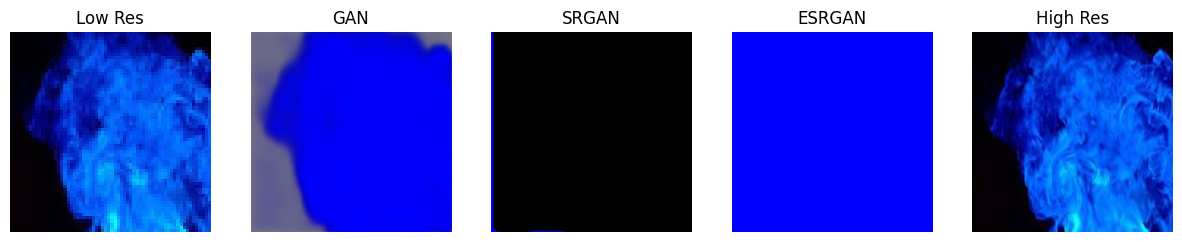

In [22]:
plt.figure(figsize=(15,6))

# Low Resolution
plt.subplot(1,5,1)
plt.imshow(lr_img[0])
plt.title("Low Res")
plt.axis('off')

# GAN
plt.subplot(1,5,2)
plt.imshow(gan_out[0])
plt.title("GAN")
plt.axis('off')

# SRGAN
plt.subplot(1,5,3)
plt.imshow(srgan_out[0])
plt.title("SRGAN")
plt.axis('off')

# ESRGAN
plt.subplot(1,5,4)
plt.imshow(esrgan_out[0])
plt.title("ESRGAN")
plt.axis('off')

plt.subplot(1,5,5)
plt.imshow(hr_img[0])
plt.title("High Res")
plt.axis('off')

plt.show()